# Predicción de Cancelación de Reservas Hoteleras - Daniel García Nilo

Máster en Data Science & IA · Evolve Academy

Revenue Management, el equipo que gestiona precios e ingresos del hotel, necesita anticipar
cancelaciones. El objetivo es estimar el riesgo al reservar para actuar a tiempo y reducir
habitaciones vacías, sin molestar innecesariamente a los clientes.

Es un problema de **clasificación binaria**: aprendemos de reservas anteriores para distinguir
dos resultados. La variable que queremos predecir, o **target**, es `is_canceled`:
**1 = cancelada; 0 = no cancelada**.

**Reserva → estimación del riesgo → acción preventiva → posible reducción de pérdidas.**

Seguimos el PDF del caso práctico y conservamos los 13 encabezados de
`solucion_cancelacion_hotelera.ipynb`. Todos los resultados proceden del CSV local.

## 0. Entorno y dependencias

Preparamos las librerías que necesitamos para leer los datos, crear gráficos y entrenar modelos.
Mostramos sus versiones para poder repetir el trabajo en el mismo entorno.

Ejecutar de arriba abajo desde la carpeta del CSV. Usamos `random_state=42` para repetir las
operaciones aleatorias con el mismo resultado. Los textos resumen la ejecución del CSV entregado.

In [1]:
# Python 3.14.5. Las versiones efectivas se muestran debajo. Si faltan dependencias:
# %pip install pandas==3.0.6 numpy==2.5.3 scikit-learn==1.8.0 matplotlib==3.10.9 shap==0.52.0 ipywidgets==8.1.9
import os
os.environ.setdefault("OMP_NUM_THREADS", "4")
import calendar
import hashlib
from importlib.metadata import version
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap
from IPython.display import display, Markdown
from scipy.special import expit
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

# Fijamos la semilla y el umbral para comparar todos los modelos igual.
SEED = 42
THRESHOLD = 0.50  # Referencia inicial; después elegimos el umbral solo con validación.
MIN_PRECISION = 0.70  # Supuesto de trabajo: al menos 7 aciertos por cada 10 alertas.
MIN_RESERVAS = 100  # Solo afecta a gráficos de categorías, nunca al dataset.
pd.set_option("display.max_columns", 12)
pd.set_option("display.float_format", "{:.3f}".format)
plt.rcParams.update({"figure.figsize": (8, 3.5), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
display(pd.Series({p: version(p) for p in
                   ["pandas", "numpy", "scikit-learn", "matplotlib", "shap"]}, name="Versión"))

pandas           3.0.6
numpy            2.5.3
scikit-learn     1.8.0
matplotlib      3.10.9
shap            0.52.0
Name: Versión, dtype: str

## 1. Carga y primera inspección

Cargamos el CSV y revisamos su tamaño, los tipos de datos, los valores ausentes y el resultado
de las reservas. Así sabemos con qué información contamos antes de analizarla.

**Aquí solo detectamos posibles problemas; todavía no los solucionamos.** Más adelante
decidiremos qué significan los nulos y las filas idénticas, y cómo tratarlos. Las relaciones
con la cancelación se estudiarán solo en los datos de entrenamiento, llamados TRAIN.

In [2]:
# Cargamos el CSV; cada fila representa una reserva.
CSV = Path("reservas_hoteleras.csv")
df_raw = pd.read_csv(CSV)
print("Dimensiones:", df_raw.shape)
print("SHA-256 del CSV:", hashlib.sha256(CSV.read_bytes()).hexdigest())
display(df_raw.head(3))
df_raw.info()
# Revisamos los nulos sin rellenarlos todavía.
resumen = pd.DataFrame({"tipo": df_raw.dtypes.astype(str),
                        "nulos": df_raw.isna().sum(),
                        "% nulos": 100 * df_raw.isna().mean()})
display(resumen.loc[resumen.nulos > 0])
# Contamos filas idénticas; más adelante decidimos cómo tratarlas.
print("Filas idénticas adicionales:", df_raw.duplicated().sum())
# Comparamos cuántas reservas cancelan y cuántas no.
target = df_raw.is_canceled.value_counts().sort_index().rename("Reservas").to_frame()
target["Proporción"] = target.Reservas / len(df_raw)
display(target.rename(index={0: "0 · No cancelada", 1: "1 · Cancelada"}))
assert set(df_raw.is_canceled.unique()) == {0, 1}

Dimensiones: (119390, 32)
SHA-256 del CSV: d9514af026b8fc13851c028e9870cd9fb08ff1883c609259293d41a07625c7cb


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,...,Transient,0.000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,...,Transient,0.000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,...,Transient,75.000,0,0,Check-Out,2015-07-02


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

,tipo,nulos,% nulos
children,float64,4,0.003
country,str,488,0.409
agent,float64,16340,13.686
company,float64,112593,94.307


Filas idénticas adicionales: 31994


,Reservas,Proporción
is_canceled,,
0 · No cancelada,75166,0.630
1 · Cancelada,44224,0.370


**Resultado:** hay 119.390 reservas y 32 variables. Aproximadamente el **37 % cancela y el 63 % no**.
Hay más ejemplos de una clase que de otra: esto se llama **desbalanceo**. No es extremo;
comprobaremos durante el modelado si dar más importancia a las cancelaciones ayuda.

Detectamos 4 nulos en `children`, 488 en `country`, 16.340 en `agent` y 112.593 en `company`.
También hay 31.994 filas idénticas adicionales. Por ahora registramos estos hallazgos;
no eliminamos ni rellenamos datos en esta primera revisión.

## 2. EDA Tecnico

Antes de buscar patrones de cancelación, revisamos la calidad de los datos. Partimos de los
nulos y posibles duplicados detectados, y comprobamos valores poco habituales e información
que no podríamos usar al predecir. Esto evita tomar decisiones basadas en errores.

**ADR** significa *Average Daily Rate*: precio medio por habitación y noche. Comprobamos
si hay precios negativos o superiores a 1.000 €, reservas sin huéspedes y estancias de cero noches.
Un valor extraño merece revisión, pero no es necesariamente un error.

También creamos la fecha de llegada y reservamos desde ahora el periodo más reciente para
TEST, la evaluación final. Así los gráficos de negocio no utilizan ese periodo.

In [3]:
# Trabajamos con un DataFrame separado para conservar los datos originales.
df = df_raw.copy()
conteos = ["lead_time", "adults", "children", "babies", "stays_in_week_nights",
           "stays_in_weekend_nights", "previous_cancellations", "previous_bookings_not_canceled"]
auditoria = pd.Series({
    "Filas con conteos negativos": int(df[conteos].lt(0).any(axis=1).sum()),
    # Buscamos precios por noche negativos: no los interpretamos como tarifas válidas.
    "ADR negativo": int(df.adr.lt(0).sum()),
    # Un precio muy alto puede ser real; lo señalamos para revisión.
    "ADR superior a 1.000 € (revisar, no eliminar)": int(df.adr.gt(1000).sum()),
    # Revisamos registros sin huéspedes; si falta un componente, no suponemos cero.
    "Reservas sin huéspedes registrados": int(df[["adults", "children", "babies"]]
                                                .sum(axis=1, min_count=3).eq(0).sum()),
    # Contamos reservas con cero noches de estancia.
    "Reservas con cero noches": int((df.stays_in_week_nights + df.stays_in_weekend_nights).eq(0).sum())
}, name="Filas")
display(auditoria)
assert not df[conteos].lt(0).any().any(), "Revisar conteos negativos antes de modelar."
# Marcamos el ADR negativo como ausente: se omite en EDA y se imputa dentro del pipeline.
df.loc[df.adr < 0, "adr"] = np.nan

# Creamos la fecha completa de llegada y dejamos TEST fuera del EDA.
MESES = {calendar.month_name[i]: i for i in range(1, 13)}
df["arrival_date"] = pd.to_datetime(dict(year=df.arrival_date_year,
                                         month=df.arrival_date_month.map(MESES),
                                         day=df.arrival_date_day_of_month), errors="raise")
df = df.sort_values("arrival_date", kind="stable")
CUTOFF = pd.Timestamp("2017-05-01")
eda = df.loc[df.arrival_date < CUTOFF].copy()
print("El EDA usa", len(eda), "reservas anteriores a", CUTOFF.date())

Filas con conteos negativos                        0
ADR negativo                                       1
ADR superior a 1.000 € (revisar, no eliminar)      1
Reservas sin huéspedes registrados               180
Reservas con cero noches                         715
Name: Filas, dtype: int64

El EDA usa 97192 reservas anteriores a 2017-05-01


**Qué encontramos y qué decidimos:**

- **31.994 filas idénticas adicionales:** no hay un identificador único de reserva. Pueden ser
  errores de duplicación o reservas distintas con las mismas características, por ejemplo de
  un grupo. Las conservamos para no borrar reservas reales sin evidencia. Al compartir fecha
  de llegada, las filas idénticas quedan en el mismo lado de cada corte temporal.
- **1 ADR negativo:** no lo interpretamos como un precio por noche válido; podría ser un error
  o un ajuste contable. Lo dejamos vacío, conservando la fila. En EDA no entra en la media; para el modelo se rellena con la mediana aprendida en TRAIN.
- **1 ADR superior a 1.000 € (5.400 €):** es extremo, pero no podemos confirmar que sea un error.
  Lo conservamos e indicamos que puede afectar a la media.
- **715 reservas con cero noches:** podrían corresponder a usos sin pernoctación o incidencias
  de registro. Sin información adicional no sabemos su origen, así que no las borramos.
- **180 reservas sin huéspedes registrados:** requieren revisar el registro de ocupantes;
  no basta para afirmar que toda la reserva es inválida. Las conservamos y anotamos esa limitación.

No hay conteos negativos en las variables revisadas. Tampoco recortamos automáticamente grupos
grandes: un tamaño poco habitual puede ser real. El ADR vuelve al modelo como aproximación al precio de la reserva; su versión inicial debe verificarse.

### Revisión de Data Leakage

**Data Leakage**, o fuga de información, significa usar al entrenar datos que no conoceríamos
al predecir. Sería dar al modelo parte de la respuesta y sobrevalorar lo que puede hacer.
**«¿Se conoce al reservar?» pregunta si el hotel dispone del dato al crear la reserva.**

| Variable | Qué representa | ¿Se conoce al reservar? | Riesgo de Data Leakage | Decisión |
|---|---|---|---|---|
| `reservation_status` | Estado final de la reserva | No | Revela directamente el resultado | Excluir |
| `reservation_status_date` | Fecha en que se registró el estado final | No | Hecho posterior a la reserva | Excluir; tampoco usar para dividir datos |
| `assigned_room_type` | Habitación finalmente asignada | No siempre | Puede decidirse después | Excluir |
| `booking_changes` | Cambios hasta la llegada o cancelación | No | Cuenta cambios futuros | Excluir |
| `days_in_waiting_list` | Días que acabó esperando hasta confirmarse | No al crearla | Duración futura de la espera | Excluir |
| `deposit_type` | Tipo de depósito realizado | No siempre | Puede reflejar pagos posteriores en este dataset | Excluir por precaución |
| `adr` | Precio medio por habitación y noche | Aproximación al precio conocido al reservar | No es fuga por sí mismo; verificar precio inicial | Conservar |
| `total_of_special_requests` | Número de peticiones especiales del cliente | Sí, si se registran al reservar | Verificar que no incluya peticiones añadidas después | Conservar bajo ese supuesto |
| `required_car_parking_spaces` | Plazas de parking solicitadas | Sí, si se solicitan al reservar | Verificar que sea la solicitud inicial | Conservar bajo ese supuesto |
| `previous_cancellations` | Cancelaciones del cliente anteriores a esta reserva | Sí, como historial anterior | No es fuga si solo recoge hechos anteriores | Conservar |
| `previous_bookings_not_canceled` | Reservas anteriores del cliente no canceladas | Sí, como historial anterior | No es fuga si su resultado ya era conocido | Conservar |
| `is_repeated_guest` | Indica si el cliente había reservado anteriormente | Sí, como historial anterior | No es fuga si se calcula al crear la reserva | Conservar |
| Fechas previstas, antelación, huéspedes, noches, habitación reservada y comidas | Datos de la solicitud | Sí en la solicitud inicial | Pueden cambiar después; necesitamos su versión inicial | Conservar como aproximación |
| Hotel, país, canal, segmento, agencia, empresa y tipo de cliente | Origen y características de la reserva | En principio sí | Verificar su versión inicial | Conservar |
| `is_canceled` | Resultado que queremos predecir | No | Es la respuesta | Solo target, nunca predictor |

**Decisión:** reincorporamos precio, solicitudes e historial; no son automáticamente fuga.
El historial anterior puede ser útil para anticipar el comportamiento del cliente.

**Limitación del dato:** el [artículo original](https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/)
describe extracciones cercanas a la llegada. El CSV no permite comprobar todos los instantes
de registro. Conservamos estas variables como aproximación académica; antes de usar el modelo
en el hotel hay que obtener su valor al reservar, sin incorporar novedades posteriores.

In [4]:
# Variables que vamos a excluir por posible Data Leakage.
LEAKAGE = ["reservation_status", "reservation_status_date", "assigned_room_type",
           "booking_changes", "days_in_waiting_list", "deposit_type"]
REINCORPORADAS = ["adr", "total_of_special_requests", "required_car_parking_spaces",
                  "previous_cancellations", "previous_bookings_not_canceled", "is_repeated_guest"]
print("Excluidas:", ", ".join(LEAKAGE))
print("Reincorporadas:", ", ".join(REINCORPORADAS))

Excluidas: reservation_status, reservation_status_date, assigned_room_type, booking_changes, days_in_waiting_list, deposit_type
Reincorporadas: adr, total_of_special_requests, required_car_parking_spaces, previous_cancellations, previous_bookings_not_canceled, is_repeated_guest


## 2. EDA — Análisis exploratorio con foco de negocio

EDA significa **análisis exploratorio de datos**. Buscamos patrones que ayuden a entender
las cancelaciones y a proponer acciones. Respondemos cinco preguntas usando solo TRAIN.

La **tasa de cancelación** es cancelaciones divididas entre reservas del grupo. Permite comparar
grupos de distinto tamaño; `n` indica cuántas reservas hay. Una relación entre dos variables
no demuestra que una provoque la otra.

**Gráficos de categorías:** mostramos solo grupos con al menos 100 reservas. Es un criterio
sencillo para no destacar porcentajes basados en unos pocos casos, no una garantía estadística.
Los registros se mantienen para entrenar y evaluar.

### ¿Se cancela más en un tipo de hotel?

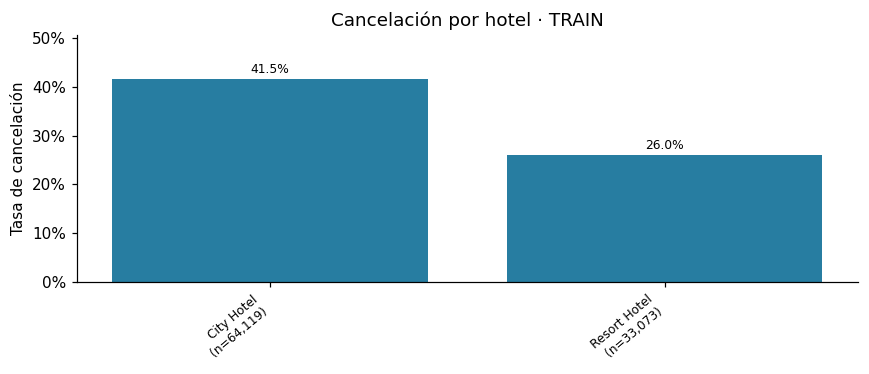

In [5]:
# Calculamos cancelaciones / reservas para comparar grupos de distinto tamaño.
def tabla_tasas(columna, datos=eda):
    return datos.groupby(columna, observed=True).is_canceled.agg(
        Reservas="size", Cancelaciones="sum", Tasa="mean")

# Reutilizamos el mismo formato de gráfico para facilitar la lectura.
def barras_tasa(tabla, titulo, ax=None):
    # Ocultamos grupos pequeños solo al dibujar; las tablas y el dataset no cambian.
    tabla = tabla.loc[tabla.Reservas >= MIN_RESERVAS]
    ax = ax if ax is not None else plt.subplots()[1]
    posiciones = np.arange(len(tabla))
    ax.bar(posiciones, tabla.Tasa, color="#277DA1")
    ax.set_xticks(posiciones, [f"{x}\n(n={n:,})" for x, n in zip(tabla.index, tabla.Reservas)],
                  rotation=40, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    ax.set_ylabel("Tasa de cancelación")
    ax.set_title(titulo)
    for p, v in zip(posiciones, tabla.Tasa):
        ax.annotate(f"{v:.1%}", (p, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=8)
    ax.set_ylim(0, min(1.1, max(0.1, tabla.Tasa.max() * 1.22)))
    return ax

hotel_rates = tabla_tasas("hotel")
barras_tasa(hotel_rates, "Cancelación por hotel · TRAIN")
plt.tight_layout(); plt.show()

**Resultado:** City Hotel tiene un **41,5 %** de cancelaciones
y Resort Hotel, un **26,0 %**. La diferencia no explica por sí sola la causa.

**Acción:** comenzar una prueba de recordatorios en City Hotel y medir si reduce cancelaciones.

### ¿Hay meses con mayor tasa de cancelación?

Comparamos el mes previsto de llegada para saber cuándo podría necesitarse más seguimiento.

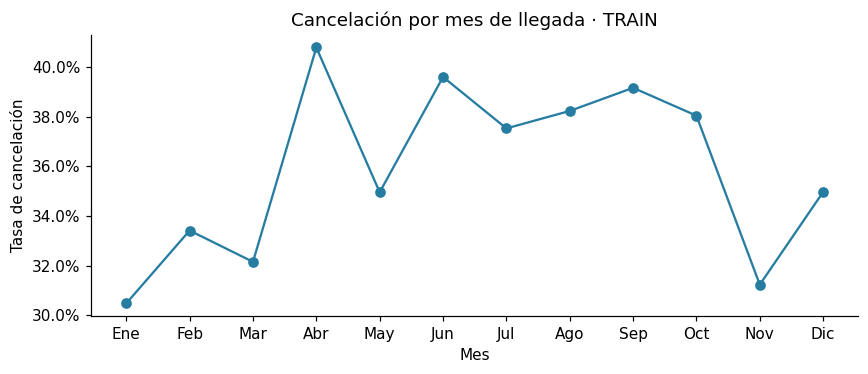

arrival_date_month,January,February,March,April,May,June,July,August,September,October,November,December
Reservas,5929.000,8068.000,9794.000,11089.000,5478.000,5292.000,7348.000,8952.000,10508.000,11160.000,6794.000,6780.000
Tasa,0.305,0.334,0.322,0.408,0.350,0.396,0.375,0.382,0.392,0.380,0.312,0.350


In [6]:
# Ordenamos los meses de enero a diciembre, no alfabéticamente.
month_rates = tabla_tasas("arrival_date_month").reindex(MESES)
ax = month_rates.Tasa.plot(marker="o", color="#277DA1")
ax.set_xticks(range(12), ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set(title="Cancelación por mes de llegada · TRAIN", xlabel="Mes", ylabel="Tasa de cancelación")
plt.tight_layout(); plt.show()
display(month_rates[["Reservas", "Tasa"]].T)

**Resultado:** abril tiene la tasa más alta de TRAIN (**40,8 %**) y
enero la menor (**30,5 %**). No todos los meses incluyen los mismos años;
la diferencia no tiene por qué deberse solo a la época del año.

**Acción:** planificar el seguimiento por mes y comprobar si el patrón se repite con más datos.

### ¿Cambia la cancelación según el canal por el que llega la reserva?

Comparamos el canal de distribución y el segmento comercial. TA/TO agrupa agencias y
operadores turísticos; Direct corresponde al canal directo y Groups al segmento de grupos.

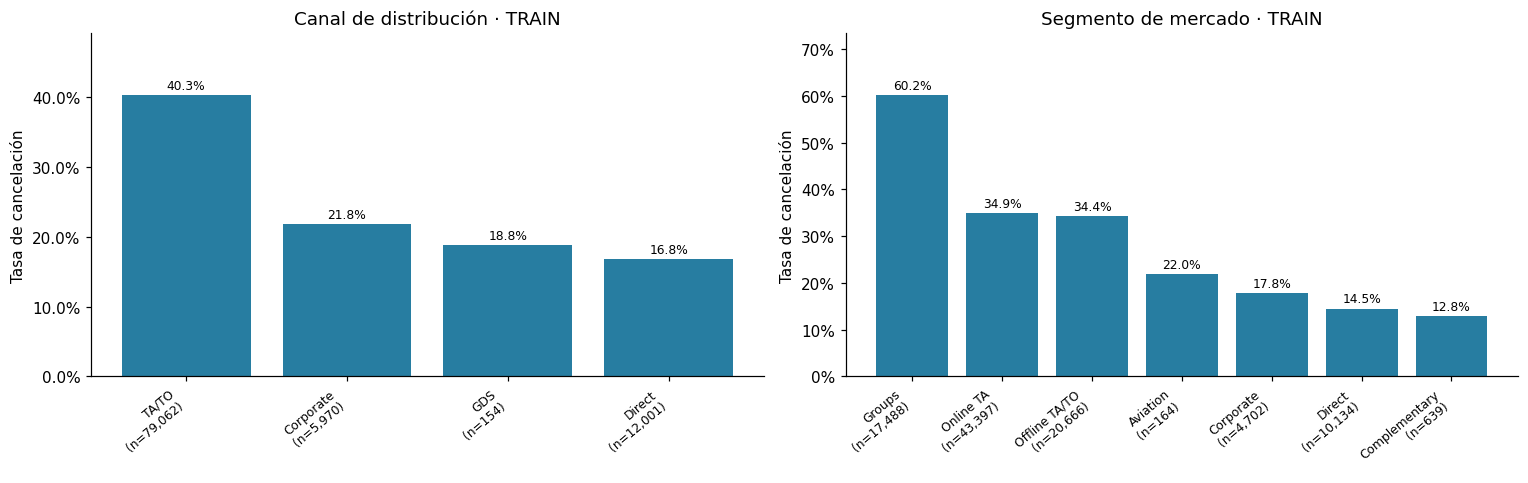

In [7]:
# Canal y segmento son dos formas distintas de describir el origen de la reserva.
channel_rates = tabla_tasas("distribution_channel").sort_values("Tasa", ascending=False)
segment_rates = tabla_tasas("market_segment").sort_values("Tasa", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
barras_tasa(channel_rates, "Canal de distribución · TRAIN", axes[0])
barras_tasa(segment_rates, "Segmento de mercado · TRAIN", axes[1])
plt.tight_layout(); plt.show()

**Resultado:** TA/TO registra **40,3 %**, frente a
**16,8 %** de Direct; el segmento Groups alcanza
**60,2 %**. Canal y segmento describen aspectos distintos de una reserva.

**Acción:** coordinar reconfirmaciones con agencias y responsables de grupos.
`Undefined` tiene solo 5 reservas en canal y
2 en segmento: se oculta en los gráficos, pero no se eliminan esas filas.

### ¿La antelación de la reserva está relacionada con la cancelación?

`lead_time` indica cuántos días pasan entre la reserva y la llegada. Lo agrupamos en intervalos
para comparar reservas hechas con poca y mucha antelación.

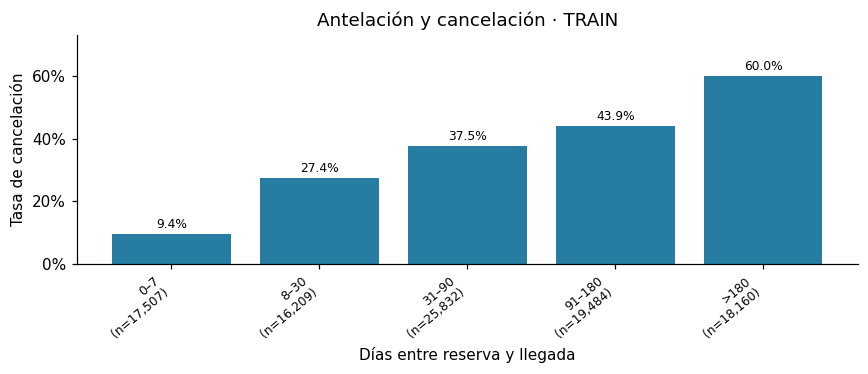

In [8]:
# Agrupamos los días de antelación en intervalos fáciles de comparar.
eda["lead_group"] = pd.cut(eda.lead_time, [-1, 7, 30, 90, 180, np.inf],
                            labels=["0–7", "8–30", "31–90", "91–180", ">180"])
lead_rates = tabla_tasas("lead_group")
barras_tasa(lead_rates, "Antelación y cancelación · TRAIN")
plt.xlabel("Días entre reserva y llegada")
plt.tight_layout(); plt.show()

**Resultado:** la cancelación pasa del **9,4 %** con 0–7 días
al **60,0 %** con más de 180 días. En estos datos, más antelación se relaciona con más cancelaciones.

**Acción:** programar reconfirmaciones durante las esperas largas sin penalizar automáticamente a quien reserva con tiempo.

### ¿El precio medio por noche cambia entre reservas canceladas y no canceladas?

**ADR (*Average Daily Rate*)** es el precio medio por habitación y noche. Comparamos la media
del ADR de las reservas que **no cancelaron** con la de las que **sí cancelaron**.
El gráfico muestra solo esos dos importes, sin mezclar el número de reservas.

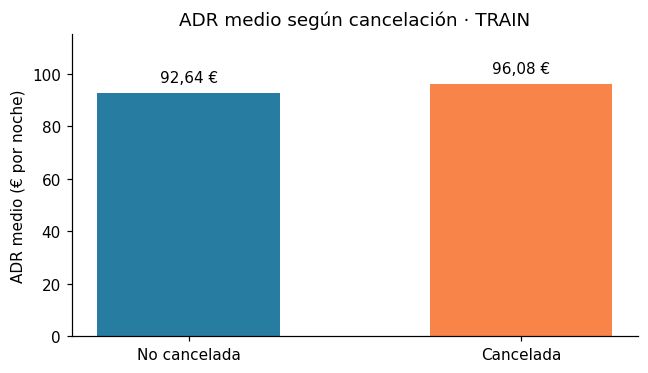

In [9]:
# Calculamos el ADR medio de cada grupo, usando solo TRAIN.
adr_stats = eda.groupby("is_canceled").adr.agg(Reservas="count", Media="mean", Mediana="median")

# Mostramos solo dos barras de precio; el eje comienza en cero para no exagerar la diferencia.
fig, ax = plt.subplots(figsize=(6, 3.5))
barras = ax.bar(["No cancelada", "Cancelada"], adr_stats.loc[[0, 1], "Media"],
                color=["#277DA1", "#F9844A"], width=0.55)
ax.set(title="ADR medio según cancelación · TRAIN", ylabel="ADR medio (€ por noche)")
ax.set_ylim(0, adr_stats.Media.max() * 1.20)

# Añadimos el importe sobre cada barra para que la pequeña diferencia se lea con claridad.
ax.bar_label(barras, labels=[f"{valor:.2f} €".replace(".", ",")
                            for valor in adr_stats.loc[[0, 1], "Media"]], padding=5)
plt.tight_layout()
plt.show()

**Resultado:** ADR medio de **92,64 €** en no canceladas y
**96,08 €** en canceladas: diferencia de **3,43 €**,
calculada antes de redondear. Las medianas son **87,00 €** y
**90,00 €**. La mediana es el valor central y depende menos de precios extremos;
la media conserva el ADR máximo de 5.400 €.

**Interpretación:** las medias son parecidas; no demuestran que subir el precio provoque cancelaciones.
**Acción:** estudiar ingresos en riesgo usando tarifas iniciales verificadas.
El ADR se utiliza también en el modelo como aproximación al precio conocido al reservar.

### Tratamiento de nulos

Ahora decidimos cómo tratar los valores ausentes según el significado de cada variable.
No todos los nulos representan lo mismo; rellenarlos sin criterio podría inventar información.

- **`agent`** identifica la agencia. Usamos `Sin_agente` cuando no hay una agencia identificada.
- **`company`** identifica la empresa. La mayoría está vacía; usamos `Sin_empresa` en lugar
  de inventar un código. Estas etiquetas significan «no registrada», no ausencia confirmada.
- **`country`** indica el país. Usamos `Desconocido` para no atribuir uno que no conocemos.
- **`children`** cuenta los niños y tiene cuatro nulos. No suponemos que sean cero. Al sumar
  huéspedes, esas cuatro sumas también quedarán vacías; después rellenaremos **`total_guests`**
  con la mediana aprendida solo en TRAIN. No rellenamos `children` directamente porque sus
  componentes se sustituyen por el total en el modelo.

Los códigos de agencia y empresa se tratan como categorías, no como cantidades.
Conservamos `Undefined` como categoría tal como aparece en el CSV.

El ADR negativo queda nulo: el pipeline lo rellenará con la mediana calculada solo con
los datos de entrenamiento de cada ajuste. No usamos TEST para calcularla.

In [10]:
# Los códigos identifican agencias o empresas; no son cantidades.
for col, ausencia in [("agent", "Sin_agente"), ("company", "Sin_empresa")]:
    df[col] = df[col].astype("Int64").astype("string").fillna(ausencia).astype(object)
# Si falta el país, indicamos que es desconocido.
df["country"] = df.country.fillna("Desconocido").astype(object)
# Los cuatro nulos de children se tratarán a través de total_guests en el pipeline.
display(df[["children", "country", "agent", "company"]].isna().sum().rename("Nulos pendientes"))

children    4
country     0
agent       0
company     0
Name: Nulos pendientes, dtype: int64

**Comprobación:** país, agencia y empresa ya no tienen nulos. Permanecen los cuatro de `children`;
es intencionado. Se trasladarán al total de huéspedes y se completarán durante el entrenamiento,
para no calcular la mediana con información de validación o TEST.
El nulo de ADR se trata de la misma forma dentro de su columna numérica.

## 3. Feature Engineering

**Feature Engineering** consiste en crear nuevas variables a partir de las existentes.
Creamos dos resúmenes fáciles de interpretar para representar mejor la reserva:

- **`total_guests = adults + children + babies`:** sumamos adultos, niños y bebés para conocer
  el tamaño del grupo. Organizar un viaje puede ser distinto según cuántas personas participan.
- **`total_nights = stays_in_week_nights + stays_in_weekend_nights`:** sumamos las noches
  entre semana y de fin de semana. La duración indica cuántas noches de habitación están comprometidas.

Usamos los totales en lugar de sus componentes para no repetir esa información.
La fecha `arrival_date` solo sirve para dividir los periodos, no entra al modelo.

In [11]:
# Sumamos huéspedes; min_count=3 mantiene el nulo si falta algún componente.
df["total_guests"] = df[["adults", "children", "babies"]].sum(axis=1, min_count=3)
# Sumamos las noches entre semana y de fin de semana.
df["total_nights"] = df.stays_in_week_nights + df.stays_in_weekend_nights
COMPONENTES = ["adults", "children", "babies", "stays_in_week_nights", "stays_in_weekend_nights"]
# Retiramos fugas, componentes sustituidos, respuesta y fecha de partición.
feature_cols = df.columns.drop(LEAKAGE + COMPONENTES + ["is_canceled", "arrival_date"]).tolist()
assert not set(LEAKAGE + ["is_canceled", "arrival_date"]) & set(feature_cols)
assert df.total_guests.isna().sum() == df.children.isna().sum()
print("Features del modelo:", feature_cols)
assert set(REINCORPORADAS).issubset(feature_cols)
assert len(df) == len(df_raw)  # El filtro visual de categorías no elimina reservas.

Features del modelo: ['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'agent', 'company', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights']


## 4. Train y Test

Comparamos modelos con reservas posteriores a las utilizadas para aprender. No mezclamos fechas al azar.

- **TRAIN/FIT:** datos con los que aprenden los modelos durante la comparación.
- **VALIDATION:** periodo posterior para elegir modelo, configuración y threshold (umbral de decisión).
- **TEST:** periodo final, que no usamos para ninguna de esas decisiones.

Revisamos cortes a principio de mes y elegimos el más cercano al 80 % de desarrollo.
Se mantiene **01/05/2017**, una fecha clara: desarrollo termina en abril y TEST empieza en mayo.
Dentro de desarrollo, reservamos aproximadamente el último 20 % para validación.
Al final reunimos ajuste y validación para entrenar el modelo ya elegido.

El corte usa fecha de **llegada**, no de creación. Una reserva de llegada posterior puede haberse
creado antes del corte: necesitamos fechas originales para simular exactamente qué sabía el hotel
en cada momento. Además, TEST ya se evaluó en versiones anteriores del trabajo; no interviene en
la selección de esta revisión, pero un periodo nuevo sería necesario para una comprobación externa.

**Porcentajes reales del total:** ajuste **65,08 %**, validación **16,33 %** y TEST **18,59 %**. Desarrollo completo: **81,41 %**.

| Conjunto | Reservas | Llegadas desde | Hasta |
|---|---:|---|---|
| TRAIN ajuste | 77.698 | 2015-07-01 | 2016-12-25 |
| TRAIN validación | 19.494 | 2016-12-26 | 2017-04-30 |
| TEST reservado | 22.198 | 2017-05-01 | 2017-08-31 |


In [12]:
# Comparamos cortes mensuales usando solo fechas y cantidades, no resultados de cancelación.
cortes = df.arrival_date.dt.to_period("M").drop_duplicates().dt.to_timestamp()
opciones_corte = pd.DataFrame({"Corte": cortes.to_numpy()})
opciones_corte["% desarrollo"] = [100 * (df.arrival_date < c).mean() for c in cortes]
opciones_corte["Distancia a 80 %"] = (opciones_corte["% desarrollo"] - 80).abs()
display(opciones_corte.sort_values("Distancia a 80 %").head(3).reset_index(drop=True))
assert opciones_corte.sort_values("Distancia a 80 %").iloc[0]["Corte"] == CUTOFF

# Reservamos las llegadas más recientes para evaluar al final.
train = df.loc[df.arrival_date < CUTOFF].copy()
test = df.loc[df.arrival_date >= CUTOFF].copy()
# Dentro de TRAIN, usamos el último periodo para comparar modelos.
val_cut = train.arrival_date.iloc[int(0.8 * len(train))]
fit = train.loc[train.arrival_date < val_cut].copy()
valid = train.loc[train.arrival_date >= val_cut].copy()

# X contiene las variables de entrada; y contiene si la reserva canceló.
X_fit, y_fit = fit[feature_cols], fit.is_canceled
X_valid, y_valid = valid[feature_cols], valid.is_canceled
X_train, y_train = train[feature_cols], train.is_canceled
X_test = test[feature_cols]  # Las etiquetas de TEST se usan solo tras elegir el ganador.
# Comprobamos que los periodos están ordenados y no comparten fechas.
assert fit.arrival_date.max() < valid.arrival_date.min()
assert train.arrival_date.max() < test.arrival_date.min()
assert not set(train.index) & set(test.index)
particiones = pd.DataFrame([
    {"Conjunto": nombre, "Reservas": len(datos), "Inicio": datos.arrival_date.min().date(),
     "Fin": datos.arrival_date.max().date(), "% total": 100 * len(datos) / len(df)}
    for nombre, datos in [("TRAIN ajuste", fit), ("TRAIN validación", valid), ("TEST reservado", test)]
]).set_index("Conjunto")
display(particiones)
print(f"TRAIN completo: {len(train):,} ({len(train)/len(df):.1%}); TEST: {len(test):,} ({len(test)/len(df):.1%})")
print(f"Cancelaciones en ajuste: {y_fit.mean():.1%}; en validación: {y_valid.mean():.1%}")

,Corte,% desarrollo,Distancia a 80 %
0,2017-05-01,81.407,1.407
1,2017-04-01,76.666,3.334
2,2017-06-01,86.695,6.695


,Reservas,Inicio,Fin,% total
Conjunto,,,,
TRAIN ajuste,77698,2015-07-01,2016-12-25,65.079
TRAIN validación,19494,2016-12-26,2017-04-30,16.328
TEST reservado,22198,2017-05-01,2017-08-31,18.593


TRAIN completo: 97,192 (81.4%); TEST: 22,198 (18.6%)
Cancelaciones en ajuste: 36.1%; en validación: 36.7%


## 5. Preprocesado

Preparamos los datos para que los modelos puedan utilizarlos. Separar números y categorías
permite aplicar a cada grupo el tratamiento adecuado.

### Variables numéricas

Incluyen antelación, fechas numéricas, huéspedes y noches; también ADR, peticiones, parking,
cancelaciones anteriores, reservas anteriores no canceladas y el indicador de cliente repetidor.

1. **`SimpleImputer`:** rellena posibles nulos con la mediana, el valor central de TRAIN.
2. **`StandardScaler`:** pone variables con escalas diferentes en una escala comparable.
   Esto ayuda a la regresión logística. Los árboles no lo necesitan, pero conservar el mismo
   paso no cambia el orden de los valores y facilita usar una preparación común.

### Variables categóricas

Incluyen hotel, mes de llegada, país, comidas, canal, segmento, agencia, empresa,
tipo de cliente y tipo de habitación reservada. Sus valores son grupos o etiquetas.

1. Completamos posibles ausencias con una categoría de desconocido.
2. **`OneHotEncoder`** convierte cada categoría en columnas de 0 y 1. Por ejemplo,
   `hotel=City Hotel` activa la columna City Hotel y deja a 0 la de Resort Hotel.
   Agrupamos categorías poco frecuentes para evitar demasiadas columnas; también admitimos
   categorías nuevas al predecir.

**`ColumnTransformer`** aplica estos tratamientos distintos a números y categorías.
**`Pipeline`** une la preparación y el modelo para repetir siempre los mismos pasos.
Las medianas, escalas y categorías se aprenden **solo con los datos usados para entrenar en
cada ajuste**, nunca con validación ni TEST.

In [13]:
# Separamos variables categóricas y numéricas.
cat_cols = X_fit.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]
preprocessor = ColumnTransformer([
    # Completamos nulos numéricos con la mediana y ponemos las escalas al mismo nivel.
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                       ("scaler", StandardScaler())]), num_cols),
    # Completamos categorías ausentes y las convertimos en columnas de 0 y 1.
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="Desconocido")),
                       ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                                min_frequency=30, max_categories=20,
                                                sparse_output=False))]), cat_cols)
], verbose_feature_names_out=False)

La preparación queda definida, pero todavía no aprende valores: lo hará al entrenar cada modelo.
Las funciones siguientes evitan repetir código. `pipeline` une preparación y modelo;
`metricas` calcula los mismos indicadores y `evaluar_validacion` entrena y guarda la comparación.
Explicamos el significado de las métricas al presentar el baseline.

In [14]:
# Cada modelo aprende su propia preparación al entrenar.
def pipeline(modelo):
    return Pipeline([("prep", clone(preprocessor)), ("model", modelo)])

# El umbral cambia Precision, Recall y F1; ROC-AUC usa las probabilidades sin convertirlas en 0/1.
def metricas(y, probas, umbral=0.50):
    pred = (probas >= umbral).astype(int)
    return {"ROC-AUC": roc_auc_score(y, probas),
            "Precision": precision_score(y, pred, zero_division=0),
            "Recall": recall_score(y, pred, zero_division=0),
            "F1": f1_score(y, pred, zero_division=0)}

modelos, resultados, probabilidades_valid = {}, {}, {}
def evaluar_validacion(nombre, modelo):
    # Entrenamos con ajuste y guardamos probabilidades únicamente de validación.
    modelos[nombre] = modelo.fit(X_fit, y_fit)
    probabilidades_valid[nombre] = modelo.predict_proba(X_valid)[:, 1]
    resultados[nombre] = metricas(y_valid, probabilidades_valid[nombre])
    return pd.DataFrame(resultados).T.rename_axis("Modelo · validación a 0,50")

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights']
Categóricas: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'agent', 'company', 'customer_type']


## 6. Modelo Baseline — Regresión Logística

El **baseline** es la referencia sencilla para comparar mejoras. Usamos regresión logística,
fácil de interpretar y exigida en el caso. Primero evaluamos todos los modelos con umbral 0,50:
una reserva se señala si su riesgo estimado es al menos 50 %. Después revisaremos ese umbral.

| Métrica | Qué significa | Cómo la usamos |
|---|---|---|
| **ROC-AUC** | Capacidad global de distinguir cancelación/no cancelación; 0,5 es similar al azar y 1 es separación perfecta | Comparamos la capacidad general y optimizamos hiperparámetros |
| **Recall** | Porcentaje de todas las cancelaciones reales que detectamos | Es especialmente importante para negocio: si es bajo, muchas cancelaciones pasan desapercibidas |
| **Precision** | De las reservas señaladas, qué proporción realmente cancela | Controla intervenciones sobre clientes que no iban a cancelar |
| **F1** | Resume el equilibrio entre Precision y Recall | Comprueba el compromiso entre ambas |

**No elegimos solo por ROC-AUC ni solo por Recall.** Buscamos equilibrio entre detección,
precisión, F1 y volumen de reservas señaladas. El mínimo provisional de Precision del 70 %
es una referencia de trabajo; los costes y la capacidad del hotel deberán validar la decisión.

**Recorrido:** Baseline → candidatos → comparación inicial → finalistas → optimización de
RF y HGB → comparación posterior → thresholds → comparación modelo + threshold → selección
final → reentrenamiento → TEST → interpretabilidad.

In [15]:
# Creamos la regresión logística y la evaluamos con la función anterior.
baseline = pipeline(LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000, random_state=SEED))
display(evaluar_validacion("Logística", baseline))

,ROC-AUC,Precision,Recall,F1
"Modelo · validación a 0,50",,,,
Logística,0.871,0.723,0.732,0.727


**Resultado en validación a 0,50:** ROC-AUC **0,8714**, Precision **72,3 %**, Recall **73,2 %**, F1 **72,7 %**.
Detectamos aproximadamente 73 de cada cien cancelaciones;
de cada cien alertas, unas 72 son correctas.

**Decisión:** usamos estos resultados recalculados como referencia. Los árboles pueden mejorar
la combinación de detección y falsas alarmas; no basta con superar una sola métrica.

## 7. Modelos candidatos

Además del baseline, comparamos Logistic Regression Balanced, Random Forest e HistGradientBoosting.
La logística balanceada da más peso a las cancelaciones al aprender; comprobaremos si esto
compensa el aumento de falsas alarmas.

**Random Forest:** combina muchos árboles de decisión entrenados de forma independiente
y utiliza su resultado conjunto para realizar la predicción.

**HistGradientBoosting:** construye árboles de forma secuencial, donde cada nuevo árbol
intenta corregir los errores de los anteriores.

Conservamos las configuraciones iniciales. En boosting, `early_stopping=False` evita
una partición aleatoria interna: todas las comprobaciones se hacen por fechas.

In [16]:
# Damos más peso a las cancelaciones durante el entrenamiento de la logística.
balanced = pipeline(LogisticRegression(C=1.0, class_weight="balanced", solver="lbfgs",
                                       max_iter=2000, random_state=SEED))
display(evaluar_validacion("Logística balanced", balanced))

,ROC-AUC,Precision,Recall,F1
"Modelo · validación a 0,50",,,,
Logística,0.871,0.723,0.732,0.727
Logística balanced,0.872,0.654,0.833,0.732


In [17]:
# Probamos dos modelos de árboles sin cambiar datos ni criterio de evaluación.
forest = pipeline(RandomForestClassifier(n_estimators=160, max_depth=14, min_samples_leaf=15,
                                          max_features="sqrt", n_jobs=4, random_state=SEED))
boosting = pipeline(HistGradientBoostingClassifier(max_iter=150, learning_rate=0.08,
                                                   max_leaf_nodes=15, l2_regularization=1.0,
                                                   early_stopping=False, random_state=SEED))
# Guardamos sus métricas en la misma tabla que el baseline.
evaluar_validacion("Random Forest", forest)
display(evaluar_validacion("HistGradientBoosting", boosting))

,ROC-AUC,Precision,Recall,F1
"Modelo · validación a 0,50",,,,
Logística,0.871,0.723,0.732,0.727
Logística balanced,0.872,0.654,0.833,0.732
Random Forest,0.895,0.832,0.571,0.677
HistGradientBoosting,0.902,0.810,0.621,0.703


### Comparación inicial · VALIDATION, threshold 0,50

Los cuatro indicadores se calculan sobre las mismas reservas. Una buena discriminación
no garantiza detectar muchas cancelaciones a un umbral concreto.

In [18]:
comparacion_inicial = pd.DataFrame(resultados).T.rename_axis("Modelo")
display(comparacion_inicial)
for nombre in ["Random Forest", "HistGradientBoosting"]:
    r = comparacion_inicial.loc[nombre]
    display(Markdown(f"**{nombre}:** ROC-AUC {r['ROC-AUC']:.4f}, Precision {r.Precision:.1%}, "
                     f"Recall {r.Recall:.1%} y F1 {r.F1:.1%}."))

,ROC-AUC,Precision,Recall,F1
Modelo,,,,
Logística,0.871,0.723,0.732,0.727
Logística balanced,0.872,0.654,0.833,0.732
Random Forest,0.895,0.832,0.571,0.677
HistGradientBoosting,0.902,0.810,0.621,0.703


**Random Forest:** ROC-AUC 0.8950, Precision 83.2%, Recall 57.1% y F1 67.7%.

**HistGradientBoosting:** ROC-AUC 0.9018, Precision 81.0%, Recall 62.1% y F1 70.3%.

### Finalistas: Random Forest e HistGradientBoosting

Optimizamos ambas familias antes de compararlas como alternativas operativas.
La logística y su versión balanceada quedan como referencias iniciales.
**Todavía no hay ganador: la unidad que seleccionamos es MODELO + THRESHOLD.**

## 8. Optimización de ambos finalistas

Los hiperparámetros son configuraciones elegidas antes de entrenar.
RandomizedSearchCV prueba 12 combinaciones de Random Forest con rangos moderados;
GridSearchCV mantiene las 4 combinaciones actuales de HistGradientBoosting.

En Random Forest variamos número de árboles (120, 160, 220), profundidad (10, 14, 18),
mínimo para dividir (2, 10, 20), mínimo por hoja (5, 15, 25), variables por división
(`sqrt`, 0,5) y peso de clases (sin ponderar o `balanced`). En HGB probamos 15 y 31 hojas,
y regularización L2 de 0,1 y 5,0; mantenemos 150 iteraciones y tasa de aprendizaje 0,08.

Ambas búsquedas utilizan **ROC-AUC medio en tres ventanas temporales de TRAIN/FIT**.
El preprocesado se aprende dentro de cada fold. TimeSeriesSplit se aplica a los días
ordenados para mantener las reservas de un mismo día juntas. VALIDATION y TEST quedan fuera.
[Documentación de TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html).

ROC-AUC se utiliza durante la optimización porque mide la capacidad general del modelo
para separar reservas canceladas y no canceladas sin depender de un threshold concreto.
La selección final también considera Recall, Precision, F1 y porcentaje de reservas señaladas.

In [19]:
# Creamos tres comprobaciones temporales: aprendemos con días anteriores y validamos después.
dias = np.sort(fit.arrival_date.unique())
folds, ventanas = [], []
for tr_dias, va_dias in TimeSeriesSplit(n_splits=3).split(dias):
    tr = np.flatnonzero(fit.arrival_date.isin(dias[tr_dias]))
    va = np.flatnonzero(fit.arrival_date.isin(dias[va_dias]))
    assert fit.iloc[tr].arrival_date.max() < fit.iloc[va].arrival_date.min()
    assert fit.iloc[va].arrival_date.max() < valid.arrival_date.min()
    assert y_fit.iloc[tr].nunique() == y_fit.iloc[va].nunique() == 2
    folds.append((tr, va))
    ventanas.append({"Train hasta": fit.iloc[tr].arrival_date.max().date(),
                     "Validación desde": fit.iloc[va].arrival_date.min().date(),
                     "Validación hasta": fit.iloc[va].arrival_date.max().date()})
display(pd.DataFrame(ventanas, index=[1, 2, 3]))

espacio_rf = {"model__n_estimators": [120, 160, 220],
              "model__max_depth": [10, 14, 18],
              "model__min_samples_split": [2, 10, 20],
              "model__min_samples_leaf": [5, 15, 25],
              "model__max_features": ["sqrt", 0.5],
              "model__class_weight": [None, "balanced"]}
search_rf = RandomizedSearchCV(clone(forest), espacio_rf, n_iter=12,
    scoring="roc_auc", cv=folds, random_state=SEED, n_jobs=1,
    refit=True, error_score="raise", verbose=1)
search_hgb = GridSearchCV(clone(boosting),
    {"model__max_leaf_nodes": [15, 31], "model__l2_regularization": [0.1, 5.0]},
    scoring="roc_auc", cv=folds, n_jobs=1, refit=True, error_score="raise", verbose=1)
busquedas = {"Random Forest optimizado": search_rf,
             "HistGradientBoosting optimizado": search_hgb}
for nombre, busqueda in busquedas.items():
    busqueda.fit(X_fit, y_fit)
    modelos[nombre] = busqueda.best_estimator_
    probabilidades_valid[nombre] = busqueda.best_estimator_.predict_proba(X_valid)[:, 1]
    resultados[nombre] = metricas(y_valid, probabilidades_valid[nombre])
    print(nombre, "· mejores hiperparámetros:", busqueda.best_params_)
    display(pd.DataFrame(busqueda.cv_results_)[["params", "mean_test_score", "std_test_score"]]
            .rename(columns={"mean_test_score": "ROC-AUC CV", "std_test_score": "Desviación CV"}))

,Train hasta,Validación desde,Validación hasta
1,2015-11-13,2015-11-14,2016-03-28
2,2016-03-28,2016-03-29,2016-08-11
3,2016-08-11,2016-08-12,2016-12-25


Fitting 3 folds for each of 12 candidates, totalling 36 fits


Random Forest optimizado · mejores hiperparámetros: {'model__n_estimators': 120, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 18, 'model__class_weight': None}


,params,ROC-AUC CV,Desviación CV
0,"{'model__n_estimators': 120, 'model__min_sampl...",0.875,0.030
1,"{'model__n_estimators': 120, 'model__min_sampl...",0.884,0.020
2,"{'model__n_estimators': 220, 'model__min_sampl...",0.864,0.037
3,"{'model__n_estimators': 120, 'model__min_sampl...",0.873,0.022
4,"{'model__n_estimators': 120, 'model__min_sampl...",0.874,0.027
5,"{'model__n_estimators': 120, 'model__min_sampl...",0.875,0.030
6,"{'model__n_estimators': 120, 'model__min_sampl...",0.879,0.031
7,"{'model__n_estimators': 160, 'model__min_sampl...",0.865,0.041
8,"{'model__n_estimators': 220, 'model__min_sampl...",0.862,0.038
9,"{'model__n_estimators': 120, 'model__min_sampl...",0.865,0.036


Fitting 3 folds for each of 4 candidates, totalling 12 fits


HistGradientBoosting optimizado · mejores hiperparámetros: {'model__l2_regularization': 0.1, 'model__max_leaf_nodes': 15}


,params,ROC-AUC CV,Desviación CV
0,"{'model__l2_regularization': 0.1, 'model__max_...",0.885,0.025
1,"{'model__l2_regularization': 0.1, 'model__max_...",0.885,0.027
2,"{'model__l2_regularization': 5.0, 'model__max_...",0.881,0.034
3,"{'model__l2_regularization': 5.0, 'model__max_...",0.883,0.032


### Comparación después de optimización · VALIDATION, threshold 0,50

La optimización busca mejorar la métrica utilizada durante la validación cruzada.
Esto no garantiza que todas las métricas mejoren en una ventana concreta de validación.

Comparamos ambas versiones de cada familia. El RF optimizado pasa al análisis de umbrales.
Para HGB conservaremos la versión inicial si el ajuste no aporta una mejora operativa útil;
comprobaremos también sus umbrales antes de cerrar esa decisión.

In [20]:
nombres_post = ["Random Forest", "Random Forest optimizado",
                "HistGradientBoosting", "HistGradientBoosting optimizado"]
comparacion_post = pd.DataFrame(resultados).T.loc[nombres_post].rename_axis("Modelo")
display(comparacion_post)
for nombre, busqueda in busquedas.items():
    display(Markdown(f"**{nombre}:** mejor ROC-AUC medio en CV temporal = {busqueda.best_score_:.4f}."))

,ROC-AUC,Precision,Recall,F1
Modelo,,,,
Random Forest,0.895,0.832,0.571,0.677
Random Forest optimizado,0.893,0.834,0.571,0.678
HistGradientBoosting,0.902,0.810,0.621,0.703
HistGradientBoosting optimizado,0.900,0.811,0.618,0.701


**Random Forest optimizado:** mejor ROC-AUC medio en CV temporal = 0.8843.

**HistGradientBoosting optimizado:** mejor ROC-AUC medio en CV temporal = 0.8853.

## 9. Análisis de thresholds y comparación final

El modelo devuelve una probabilidad. El threshold es el punto a partir del cual convertimos
esa probabilidad en una predicción de cancelación.

- Threshold = 0,50: riesgo ≥ 50 % se marca como cancelación.
- Threshold = 0,30: riesgo ≥ 30 % se marca como cancelación.

Bajar el threshold suele aumentar Recall, pero también genera más falsas alarmas y reduce Precision.
Un Recall muy alto permite detectar más cancelaciones, pero puede conseguirse marcando
demasiadas reservas como riesgo. Esto aumenta los falsos positivos y el número de clientes
sobre los que habría que actuar. Por este motivo buscamos un equilibrio entre Recall y
Precision, teniendo también en cuenta cuántas reservas quedarían señaladas.

Probamos **0,20; 0,25; 0,30; 0,35; 0,40; 0,45; 0,50; 0,55; 0,60** solo en VALIDATION.
La tabla auxiliar permite revisar las dos versiones de HGB; después dejamos únicamente
los dos finalistas en la tabla y en los gráficos.

**Criterio de lectura, no máximo Recall automático:** buscamos buena discriminación,
Precision al menos cercana al 70 %, Recall razonablemente alto y F1 competitivo.
Entre alternativas con equilibrio parecido preferimos menos falsas alarmas e intervenciones.
Los umbrales candidatos y la decisión se documentan tras leer esta comparación.
Sin una estimación económica del coste del falso negativo y del falso positivo,
no existe un único modelo objetivamente perfecto.

In [21]:
# ROC-AUC se calcula una vez por modelo y se repite como referencia en la tabla.
UMBRALES = np.array([0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60])
filas = []
for nombre in ["Random Forest optimizado", "HistGradientBoosting", "HistGradientBoosting optimizado"]:
    probas = probabilidades_valid[nombre]
    auc_modelo = resultados[nombre]["ROC-AUC"]
    for umbral in UMBRALES:
        pred = probas >= umbral
        filas.append({"Modelo": nombre, "Threshold": umbral, "ROC-AUC": auc_modelo,
                      "Precision": precision_score(y_valid, pred, zero_division=0),
                      "Recall": recall_score(y_valid, pred, zero_division=0),
                      "F1": f1_score(y_valid, pred, zero_division=0),
                      "% reservas señaladas": 100 * pred.mean()})
tabla_umbrales_auxiliar = pd.DataFrame(filas)
display(tabla_umbrales_auxiliar)
assert tabla_umbrales_auxiliar.groupby("Modelo")["ROC-AUC"].nunique().eq(1).all()

,Modelo,Threshold,ROC-AUC,Precision,Recall,F1,% reservas señaladas
0,Random Forest optimizado,0.200,0.893,0.608,0.913,0.730,55.027
1,Random Forest optimizado,0.250,0.893,0.659,0.872,0.751,48.543
2,Random Forest optimizado,0.300,0.893,0.718,0.778,0.746,39.730
3,Random Forest optimizado,0.350,0.893,0.772,0.692,0.730,32.882
4,Random Forest optimizado,0.400,0.893,0.793,0.648,0.714,29.958
5,Random Forest optimizado,0.450,0.893,0.816,0.614,0.700,27.573
6,Random Forest optimizado,0.500,0.893,0.834,0.571,0.678,25.115
7,Random Forest optimizado,0.550,0.893,0.848,0.538,0.658,23.233
8,Random Forest optimizado,0.600,0.893,0.872,0.478,0.617,20.088
9,HistGradientBoosting,0.200,0.902,0.689,0.845,0.759,44.942


In [23]:
# Decision razonada con VALIDATION; no usa etiquetas de TEST.
umbrales_candidatos = {'Random Forest optimizado': 0.3, 'HistGradientBoosting': 0.3}
ganador = 'HistGradientBoosting'
justificacion_validacion = """**Decisión razonada con VALIDATION, antes de consultar TEST:**

- **Random Forest optimizado a 0,30:** ROC-AUC 0,8933, Precision 71,8 %, Recall 77,8 %, F1 74,6 % y 39,7 % de reservas señaladas. A 0,25 consigue Recall 87,2 %, pero Precision cae al 65,9 % y señala el 48,5 %. A 0,35 mejora Precision al 77,2 %, a costa de Recall 69,2 % y F1 73,0 %. Elegimos 0,30 como su candidato operativo dentro del rango probado.
- **HistGradientBoosting inicial a 0,30:** ROC-AUC 0,9018, Precision 76,2 %, Recall 75,3 %, F1 75,7 % y 36,2 % señaladas. Frente a RF optimizado pierde 2,5 puntos de Recall, pero gana 4,4 puntos de Precision y 1,1 de F1, y reduce en 3,5 puntos el porcentaje de reservas que habría que atender. Su discriminación global también es mejor.
- **Por qué HGB a 0,30 y no a 0,25:** a 0,25 obtiene Recall 80,0 %, Precision 72,5 %, F1 76,1 % y 40,5 % señaladas. El F1 solo mejora 0,35 puntos, mientras las intervenciones aumentan 4,25 puntos. A 0,30 se conserva un Recall del 75,3 % y se reduce la carga. Es una preferencia operativa provisional, no un óptimo económico demostrado. A 0,35 el Recall ya baja al 71,7 % y el F1 al 74,7 %.
- **Por qué conservar HGB inicial:** el ajuste obtiene ROC-AUC 0,8998 frente a 0,9018. A 0,30 su Precision es 76,3 %, Recall 75,0 %, F1 75,7 % y señala 36,1 %. Esa variación mínima en Precision y volumen no compensa la menor discriminación y detección. Su mejor resultado dentro de la búsqueda no obliga a sustituir la configuración inicial.
- **La optimización tampoco garantiza mejorar RF en VALIDATION:** su ROC-AUC pasa de 0,8950 a 0,8933; a 0,50 Precision y F1 mejoran apenas. Se mantiene el RF optimizado como finalista solicitado, sin presentar el tuning como una mejora universal.

**Elegimos HistGradientBoosting inicial + threshold 0,30.** Mantiene un Recall razonablemente alto, mejora la calidad de las alertas y F1 frente al RF optimizado y requiere menos intervenciones. Una operación que valore mucho más los falsos negativos podría preferir otro umbral. Sin costes de FP/FN y capacidad de contacto no existe una única alternativa objetivamente perfecta; no seleccionamos por máximo Recall ni solo por ROC-AUC."""

### Precision y Recall frente al threshold

La línea vertical marca el umbral candidato de cada finalista; la horizontal recuerda
el mínimo provisional de Precision. La tabla final resume solo las dos alternativas.

,Modelo,Threshold,ROC-AUC,Precision,Recall,F1,% reservas señaladas
0,Random Forest optimizado,0.200,0.893,0.608,0.913,0.730,55.027
1,Random Forest optimizado,0.250,0.893,0.659,0.872,0.751,48.543
2,Random Forest optimizado,0.300,0.893,0.718,0.778,0.746,39.730
3,Random Forest optimizado,0.350,0.893,0.772,0.692,0.730,32.882
4,Random Forest optimizado,0.400,0.893,0.793,0.648,0.714,29.958
5,Random Forest optimizado,0.450,0.893,0.816,0.614,0.700,27.573
6,Random Forest optimizado,0.500,0.893,0.834,0.571,0.678,25.115
7,Random Forest optimizado,0.550,0.893,0.848,0.538,0.658,23.233
8,Random Forest optimizado,0.600,0.893,0.872,0.478,0.617,20.088
9,HistGradientBoosting,0.200,0.902,0.689,0.845,0.759,44.942


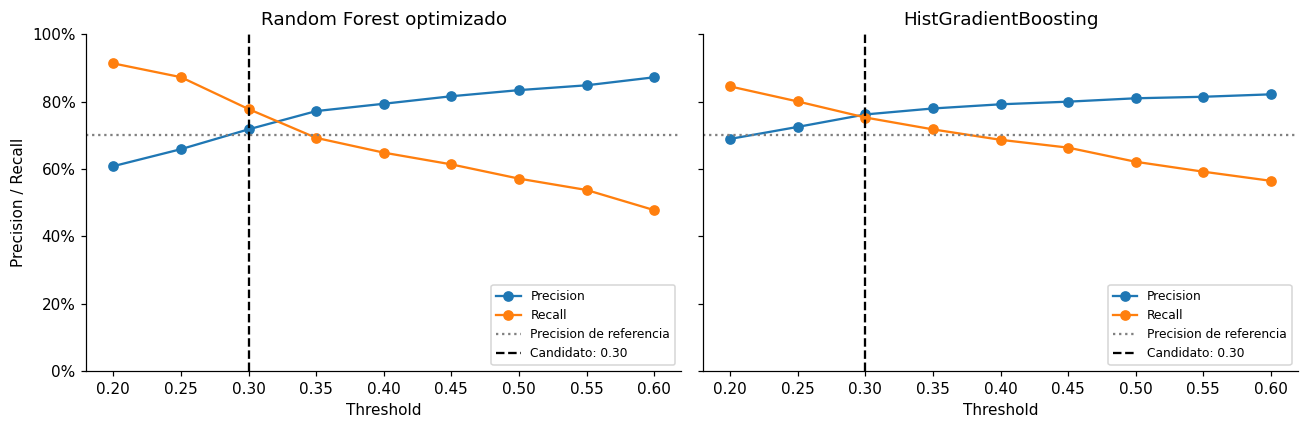

,Modelo,Threshold,ROC-AUC,Precision,Recall,F1,% reservas señaladas
0,Random Forest optimizado,0.300,0.893,0.718,0.778,0.746,39.730
1,HistGradientBoosting,0.300,0.902,0.762,0.753,0.757,36.221


**Decisión razonada con VALIDATION, antes de consultar TEST:**

- **Random Forest optimizado a 0,30:** ROC-AUC 0,8933, Precision 71,8 %, Recall 77,8 %, F1 74,6 % y 39,7 % de reservas señaladas. A 0,25 consigue Recall 87,2 %, pero Precision cae al 65,9 % y señala el 48,5 %. A 0,35 mejora Precision al 77,2 %, a costa de Recall 69,2 % y F1 73,0 %. Elegimos 0,30 como su candidato operativo dentro del rango probado.
- **HistGradientBoosting inicial a 0,30:** ROC-AUC 0,9018, Precision 76,2 %, Recall 75,3 %, F1 75,7 % y 36,2 % señaladas. Frente a RF optimizado pierde 2,5 puntos de Recall, pero gana 4,4 puntos de Precision y 1,1 de F1, y reduce en 3,5 puntos el porcentaje de reservas que habría que atender. Su discriminación global también es mejor.
- **Por qué HGB a 0,30 y no a 0,25:** a 0,25 obtiene Recall 80,0 %, Precision 72,5 %, F1 76,1 % y 40,5 % señaladas. El F1 solo mejora 0,35 puntos, mientras las intervenciones aumentan 4,25 puntos. A 0,30 se conserva un Recall del 75,3 % y se reduce la carga. Es una preferencia operativa provisional, no un óptimo económico demostrado. A 0,35 el Recall ya baja al 71,7 % y el F1 al 74,7 %.
- **Por qué conservar HGB inicial:** el ajuste obtiene ROC-AUC 0,8998 frente a 0,9018. A 0,30 su Precision es 76,3 %, Recall 75,0 %, F1 75,7 % y señala 36,1 %. Esa variación mínima en Precision y volumen no compensa la menor discriminación y detección. Su mejor resultado dentro de la búsqueda no obliga a sustituir la configuración inicial.
- **La optimización tampoco garantiza mejorar RF en VALIDATION:** su ROC-AUC pasa de 0,8950 a 0,8933; a 0,50 Precision y F1 mejoran apenas. Se mantiene el RF optimizado como finalista solicitado, sin presentar el tuning como una mejora universal.

**Elegimos HistGradientBoosting inicial + threshold 0,30.** Mantiene un Recall razonablemente alto, mejora la calidad de las alertas y F1 frente al RF optimizado y requiere menos intervenciones. Una operación que valore mucho más los falsos negativos podría preferir otro umbral. Sin costes de FP/FN y capacidad de contacto no existe una única alternativa objetivamente perfecta; no seleccionamos por máximo Recall ni solo por ROC-AUC.

In [24]:
tabla_umbrales = tabla_umbrales_auxiliar.loc[
    tabla_umbrales_auxiliar.Modelo.isin(umbrales_candidatos)].copy()
display(tabla_umbrales)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (nombre, umbral) in zip(axes, umbrales_candidatos.items()):
    datos = tabla_umbrales.loc[tabla_umbrales.Modelo == nombre]
    ax.plot(datos.Threshold, datos.Precision, marker="o", label="Precision")
    ax.plot(datos.Threshold, datos.Recall, marker="o", label="Recall")
    ax.axhline(MIN_PRECISION, color="gray", ls=":", label="Precision de referencia")
    ax.axvline(umbral, color="black", ls="--", label=f"Candidato: {umbral:.2f}")
    ax.set(title=nombre, xlabel="Threshold", ylim=(0, 1), xticks=UMBRALES)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    ax.legend(fontsize=8)
axes[0].set_ylabel("Precision / Recall")
plt.tight_layout(); plt.show()
comparacion_final = pd.concat([
    tabla_umbrales.loc[(tabla_umbrales.Modelo == nombre) & np.isclose(tabla_umbrales.Threshold, umbral)]
    for nombre, umbral in umbrales_candidatos.items()], ignore_index=True)
assert len(comparacion_final) == 2
display(comparacion_final)
display(Markdown(justificacion_validacion))

### Curva ROC de los modelos principales · VALIDATION

ROC-AUC mide la capacidad global de discriminación y no depende del threshold seleccionado.
El eje horizontal muestra falsas alarmas entre las reservas que no cancelan y el vertical
las cancelaciones detectadas. La curva complementa la comparación operativa; no decide por sí sola el ganador.

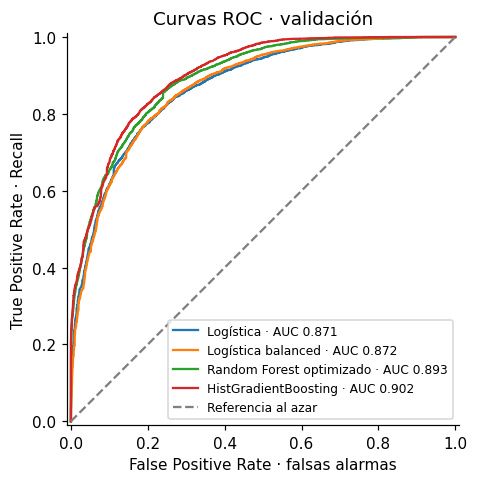

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for nombre in ["Logística", "Logística balanced", *umbrales_candidatos]:
    curva = RocCurveDisplay.from_predictions(y_valid, probabilidades_valid[nombre], ax=ax, name=nombre)
    curva.line_.set_label(f"{nombre} · AUC {resultados[nombre]['ROC-AUC']:.3f}")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Referencia al azar")
ax.set(title="Curvas ROC · validación", xlabel="False Positive Rate · falsas alarmas",
       ylabel="True Positive Rate · Recall")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

### Selección final · MODELO + THRESHOLD

Fijamos la combinación justificada en validación. No se ordenan los candidatos por máximo Recall.
El código comprueba que el umbral elegido pertenece a la comparación anterior.
Los hiperparámetros son los del pipeline de esa versión; no se modifican tras consultar TEST.

In [26]:
THRESHOLD = float(umbrales_candidatos[ganador])
seleccion = comparacion_final.loc[comparacion_final.Modelo == ganador].iloc[0]
assert np.isclose(THRESHOLD, seleccion.Threshold)
parametros_finales = modelos[ganador].named_steps["model"].get_params()
display(Markdown(f"**Decisión cerrada antes de TEST: {ganador}, threshold {THRESHOLD:.2f}.**"))
display(pd.Series(parametros_finales, name="Configuración final"))

**Decisión cerrada antes de TEST: HistGradientBoosting, threshold 0.30.**

categorical_features    from_dtype
class_weight                  None
early_stopping               False
interaction_cst               None
l2_regularization            1.000
learning_rate                0.080
loss                      log_loss
max_bins                       255
max_depth                     None
max_features                 1.000
max_iter                       150
max_leaf_nodes                  15
min_samples_leaf                20
monotonic_cst                 None
n_iter_no_change                10
random_state                    42
scoring                       loss
tol                          0.000
validation_fraction          0.100
verbose                          0
warm_start                   False
Name: Configuración final, dtype: object

## 10. Reentrenamiento y evaluación final en TEST

Reentrenamos con todo TRAIN de desarrollo (ajuste + validación), incluyendo el preprocesado.
Después obtenemos las probabilidades de TEST una sola vez y las reutilizamos para métricas,
matriz e interpretabilidad. Ningún resultado de TEST cambia el modelo, sus parámetros o el umbral.

,ROC-AUC,Precision,Recall,F1,% reservas señaladas
TEST final · umbral 0.30,,,,,
HistGradientBoosting,0.891,0.682,0.890,0.773,52.910


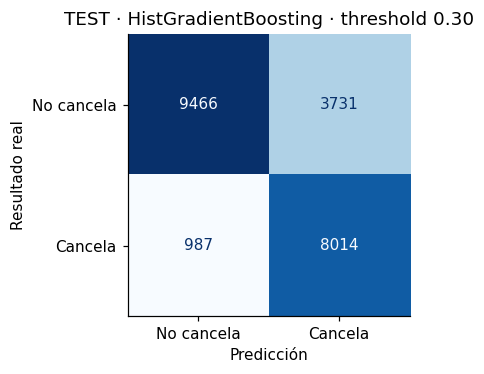

**Resultado final:** ROC-AUC **0.8914**,
Precision **68.2%**, Recall **89.0%**,
F1 **77.3%**, reservas señaladas **52.9 %**.

- **True Positive (TP): 8,014** reservas que cancelan y fueron detectadas.
- **False Negative (FN): 987** reservas que cancelan pero no fueron detectadas;
  se pierde la oportunidad de actuar y revender la habitación.
- **False Positive (FP): 3,731** reservas que no cancelan pero se marcaron como riesgo;
  implican contactos innecesarios y carga para el equipo.
- **True Negative (TN): 9,466** reservas que no cancelan y fueron correctamente clasificadas.

El **31.8%** de las alertas son falsas.
No se mantiene
la referencia provisional de Precision del **70%** en este periodo.
No reajustamos usando TEST. El volumen de intervención y los costes deben comprobarse en un piloto.

In [27]:
# Volvemos a entrenar el ganador con todo TRAIN, incluida su validación.
modelo_final = clone(modelos[ganador]).fit(X_train, y_train)
assert modelo_final.named_steps["model"].get_params() == parametros_finales
# Evaluamos una única vez en TEST con modelo y umbral ya fijados en validación.
y_test = test.is_canceled
p_test = modelo_final.predict_proba(X_test)[:, 1]
pred_test = p_test >= THRESHOLD
metricas_test = {**metricas(y_test, p_test, umbral=THRESHOLD),
                 "% reservas señaladas": 100 * pred_test.mean()}
display(pd.DataFrame([metricas_test], index=[ganador]).rename_axis(f"TEST final · umbral {THRESHOLD:.2f}"))
# Las filas son resultados reales y las columnas son predicciones.
cm = confusion_matrix(y_test, pred_test, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["No cancela", "Cancela"]).plot(cmap="Blues", colorbar=False)
plt.title(f"TEST · {ganador} · threshold {THRESHOLD:.2f}")
plt.xlabel("Predicción"); plt.ylabel("Resultado real")
plt.tight_layout(); plt.show()
tn, fp, fn, tp = cm.ravel()
assert cm.sum() == len(test)
display(Markdown(f"""**Resultado final:** ROC-AUC **{metricas_test['ROC-AUC']:.4f}**,
Precision **{metricas_test['Precision']:.1%}**, Recall **{metricas_test['Recall']:.1%}**,
F1 **{metricas_test['F1']:.1%}**, reservas señaladas **{metricas_test['% reservas señaladas']:.1f} %**.

- **True Positive (TP): {tp:,}** reservas que cancelan y fueron detectadas.
- **False Negative (FN): {fn:,}** reservas que cancelan pero no fueron detectadas;
  se pierde la oportunidad de actuar y revender la habitación.
- **False Positive (FP): {fp:,}** reservas que no cancelan pero se marcaron como riesgo;
  implican contactos innecesarios y carga para el equipo.
- **True Negative (TN): {tn:,}** reservas que no cancelan y fueron correctamente clasificadas.

El **{1-metricas_test['Precision']:.1%}** de las alertas son falsas.
{'Se mantiene' if metricas_test['Precision'] >= MIN_PRECISION else 'No se mantiene'}
la referencia provisional de Precision del **{MIN_PRECISION:.0%}** en este periodo.
No reajustamos usando TEST. El volumen de intervención y los costes deben comprobarse en un piloto."""))

## 11. Interpretabilidad

**SHAP es una técnica que permite entender por qué el modelo realiza sus predicciones.**
Muestra qué variables aumentan o reducen el riesgo estimado de cancelación.

- **Summary Plot:** qué variables influyen más globalmente. Usamos 250 reservas de TEST
  elegidas al azar con semilla fija, sin mirar si cancelaron.
- **Waterfall Plot:** qué variables suben o bajan el riesgo de una reserva concreta.
  Elegimos la de mayor y menor riesgo estimado del modelo final.

En el Summary, **derecha = sube el riesgo; izquierda = baja**. Rojo indica un valor alto y azul
uno bajo; en columnas de categorías, 1 significa que está presente. En las variables numéricas, los valores del gráfico están estandarizados: un valor negativo
no significa peticiones o plazas negativas. Las tablas locales muestran los valores originales. Se explica el modelo recién entrenado con las variables reincorporadas.

SHAP explica la probabilidad o puntuación, no el umbral que usamos para actuar.
La celda indica su escala: si aparece **log-odds**, es una escala interna del riesgo, no puntos
porcentuales. SHAP muestra asociaciones del modelo, **no causas**.
[Referencia técnica de SHAP](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html).

SHAP expresado en log-odds de cancelación · aditividad verificada contra predict_proba.


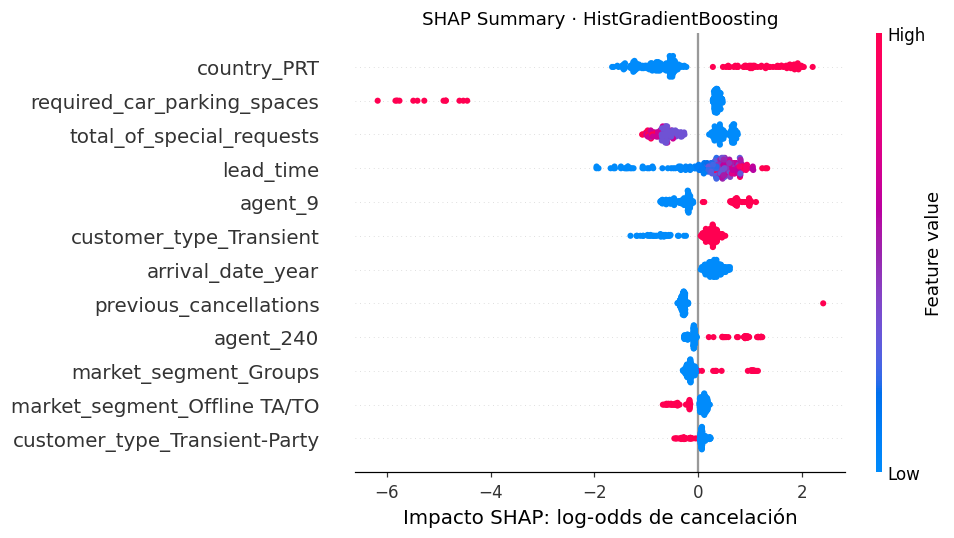

,SHAP absoluto medio
Variable,
country,1.238
agent,0.909
required_car_parking_spaces,0.622
total_of_special_requests,0.585
lead_time,0.568
customer_type,0.447
market_segment,0.405
arrival_date_year,0.310


In [28]:
# Recuperamos el modelo entrenado y los nombres de las columnas que recibe.
prep_final = modelo_final.named_steps["prep"]
estimador = modelo_final.named_steps["model"]
nombres = prep_final.get_feature_names_out().tolist()
# Elegimos la muestra para SHAP sin mirar si las reservas cancelaron.
X_explain = X_test.sample(n=min(250, len(X_test)), random_state=SEED)
X_explain_t = prep_final.transform(X_explain)
indices_casos = [int(np.argmax(p_test)), int(np.argmin(p_test))]
casos = X_test.iloc[indices_casos]
casos_t = prep_final.transform(casos)

# Elegimos el explicador adecuado para el tipo de modelo ganador.
if isinstance(estimador, LogisticRegression):
    background = prep_final.transform(X_train.sample(n=min(100, len(X_train)), random_state=SEED))
    explainer = shap.LinearExplainer(estimador, background, feature_names=nombres)
    unidad_shap = "log-odds de cancelación"
else:
    explainer = shap.TreeExplainer(estimador, feature_perturbation="tree_path_dependent", feature_names=nombres)
    unidad_shap = "probabilidad de cancelación" if isinstance(estimador, RandomForestClassifier) else "log-odds de cancelación"

def explicar(matriz):
    resultado = explainer(matriz)
    if resultado.values.ndim == 3:
        resultado = resultado[:, :, 1]  # Clase positiva en Random Forest.
    return resultado

shap_global = explicar(X_explain_t)
shap_casos = explicar(casos_t)
assert shap_global.values.shape == X_explain_t.shape
assert shap_casos.values.shape == casos_t.shape
assert list(shap_global.feature_names) == nombres
reconstruido_global = shap_global.base_values + shap_global.values.sum(axis=1)
if unidad_shap.startswith("log-odds"):
    reconstruido_global = expit(reconstruido_global)
np.testing.assert_allclose(reconstruido_global, p_test[X_test.index.get_indexer(X_explain.index)], atol=1e-5)
# Comprobamos que la suma de los aportes reproduce la predicción.
reconstruido = shap_casos.base_values + shap_casos.values.sum(axis=1)
if unidad_shap.startswith("log-odds"):
    reconstruido = expit(reconstruido)
np.testing.assert_allclose(reconstruido, p_test[indices_casos], atol=1e-5)
print("SHAP expresado en", unidad_shap, "· aditividad verificada contra predict_proba.")
shap.summary_plot(shap_global.values, X_explain_t, feature_names=nombres,
                  max_display=12, show=False, plot_size=(9, 5))
plt.title("SHAP Summary · " + ganador)
plt.xlabel("Impacto SHAP: " + unidad_shap)
plt.tight_layout(); plt.show()

# Reunimos las columnas One-Hot de cada variable para resumir su importancia.
origen = []
for nombre in nombres:
    if nombre in num_cols:
        origen.append(nombre)
    else:
        origen.append(next(c for c in sorted(cat_cols, key=len, reverse=True) if nombre.startswith(c + "_")))
shap_importance = (pd.DataFrame({"Variable": origen, "SHAP absoluto medio": np.abs(shap_global.values).mean(axis=0)})
                   .groupby("Variable")["SHAP absoluto medio"].sum().sort_values(ascending=False))
display(shap_importance.head(8).to_frame())

# Resumimos el sentido de los aportes para contrastar las explicaciones con el gráfico.
shap_direccion = []
for j, nombre in enumerate(nombres):
    valores = X_explain_t[:, j]
    mediana = np.median(valores)
    altos = valores > mediana
    if altos.any() and (~altos).any():
        shap_direccion.append({"variable": nombre,
                               "importancia": float(np.abs(shap_global.values[:, j]).mean()),
                               "aporte_valores_altos": float(shap_global.values[altos, j].mean()),
                               "aporte_valores_bajos": float(shap_global.values[~altos, j].mean())})


In [29]:
display(Markdown(f"**Ranking SHAP de {ganador}:** " +
                 ", ".join(f"`{x}`" for x in shap_importance.head(8).index) +
                 f". Se recalcula sobre {len(X_explain)} reservas del modelo final reentrenado, en {unidad_shap}."))
direccion = pd.DataFrame(shap_direccion).sort_values("importancia", ascending=False)
display(direccion.head(10).drop(columns="importancia"))
display(Markdown("**Cómo leerlo:** un aporte medio positivo aumenta el riesgo y uno negativo lo reduce. "
                 "La tabla contrasta valores por encima de la mediana con el resto de la muestra. "
                 "El ranking agrupado suma magnitudes de columnas de la misma variable; no mide causas."))
for variable in ["total_of_special_requests", "lead_time", "previous_cancellations", "required_car_parking_spaces", "adr"]:
    fila = direccion.loc[direccion.variable == variable]
    puesto = shap_importance.index.get_loc(variable) + 1
    if not fila.empty:
        r = fila.iloc[0]
        display(Markdown(f"- **{variable} (puesto {puesto}):** valores por encima de la mediana "
                         f"tienen aporte medio {r.aporte_valores_altos:+.3f}; el resto, "
                         f"{r.aporte_valores_bajos:+.3f} ({unidad_shap})."))
    else:
        display(Markdown(f"- **{variable} (puesto {puesto}):** no hay variación suficiente "
                         "en esta muestra para contrastar los dos grupos."))

**Ranking SHAP de HistGradientBoosting:** `country`, `agent`, `required_car_parking_spaces`, `total_of_special_requests`, `lead_time`, `customer_type`, `market_segment`, `arrival_date_year`. Se recalcula sobre 250 reservas del modelo final reentrenado, en log-odds de cancelación.

,variable,aporte_valores_altos,aporte_valores_bajos
31,country_PRT,1.393,-0.802
7,required_car_parking_spaces,-5.227,0.369
8,total_of_special_requests,-0.830,0.057
0,lead_time,0.629,-0.150
63,agent_9,0.789,-0.341
4,previous_cancellations,2.411,-0.286
51,agent_240,0.889,-0.122
38,market_segment_Groups,0.726,-0.156
39,market_segment_Offline TA/TO,-0.355,0.113
71,customer_type_Transient-Party,-0.249,0.081


**Cómo leerlo:** un aporte medio positivo aumenta el riesgo y uno negativo lo reduce. La tabla contrasta valores por encima de la mediana con el resto de la muestra. El ranking agrupado suma magnitudes de columnas de la misma variable; no mide causas.

- **total_of_special_requests (puesto 4):** valores por encima de la mediana tienen aporte medio -0.830; el resto, +0.057 (log-odds de cancelación).

- **lead_time (puesto 5):** valores por encima de la mediana tienen aporte medio +0.629; el resto, -0.150 (log-odds de cancelación).

- **previous_cancellations (puesto 9):** valores por encima de la mediana tienen aporte medio +2.411; el resto, -0.286 (log-odds de cancelación).

- **required_car_parking_spaces (puesto 3):** valores por encima de la mediana tienen aporte medio -5.227; el resto, +0.369 (log-odds de cancelación).

- **adr (puesto 14):** valores por encima de la mediana tienen aporte medio +0.040; el resto, +0.000 (log-odds de cancelación).

**Mayor riesgo estimado · fila CSV 11901 · riesgo estimado 99.4%**

,Valor original
hotel,Resort Hotel
lead_time,323
arrival_date_year,2017
arrival_date_month,June
arrival_date_week_number,22
arrival_date_day_of_month,3
meal,BB
country,PRT
market_segment,Groups
distribution_channel,TA/TO


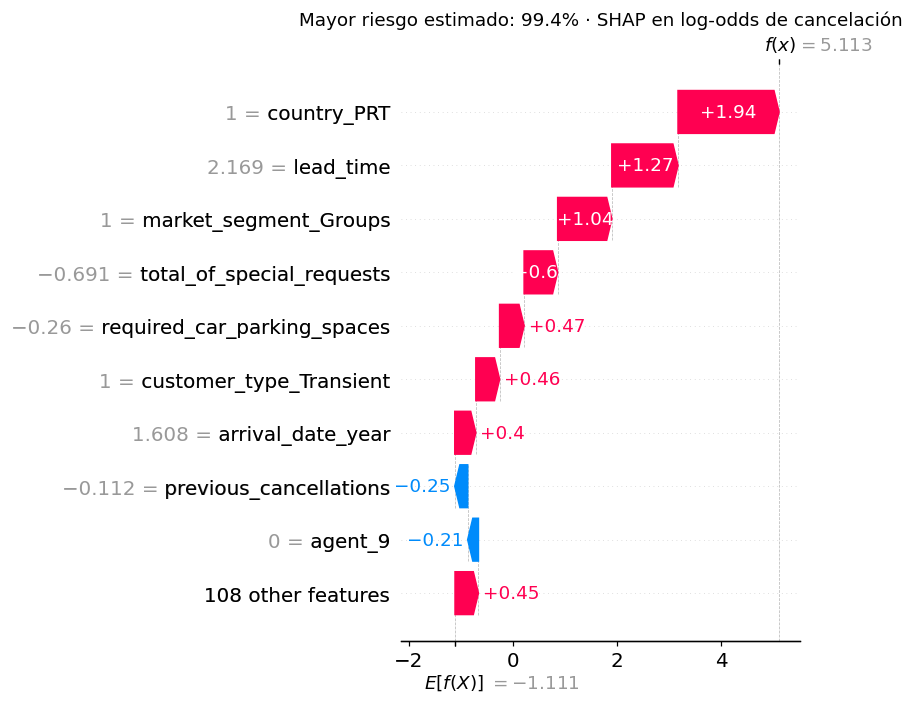

Aumentan el riesgo: country_PRT (+1.941); lead_time (+1.271); market_segment_Groups (+1.040)
Reducen el riesgo: previous_cancellations (-0.248); agent_9 (-0.206); arrival_date_week_number (-0.129)


**Menor riesgo estimado · fila CSV 15149 · riesgo estimado 0.0%**

,Valor original
hotel,Resort Hotel
lead_time,11
arrival_date_year,2017
arrival_date_month,May
arrival_date_week_number,21
arrival_date_day_of_month,24
meal,BB
country,IRL
market_segment,Online TA
distribution_channel,TA/TO


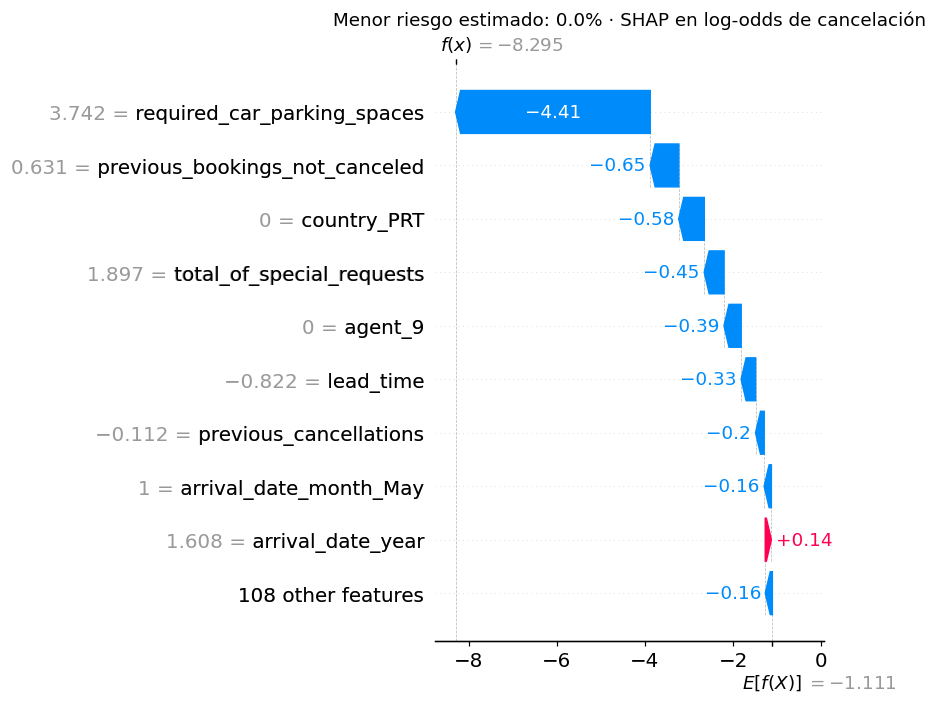

Aumentan el riesgo: arrival_date_year (+0.137); customer_type_Transient (+0.105); market_segment_Offline TA/TO (+0.060)
Reducen el riesgo: required_car_parking_spaces (-4.413); previous_bookings_not_canceled (-0.649); country_PRT (-0.577)


,TEST completo,Decil superior de riesgo
lead_time,124.000,181.000
adr,127.600,110.000
total_of_special_requests,1.000,0.000
previous_cancellations,0.000,0.000
required_car_parking_spaces,0.000,0.000


,TEST completo,Decil superior de riesgo
hotel,,
City Hotel,0.685,0.889
Resort Hotel,0.315,0.111


In [30]:
# Mostramos los dos casos y los factores que más suben o bajan su riesgo.
explicaciones_locales = []
for i, etiqueta in enumerate(["Mayor riesgo estimado", "Menor riesgo estimado"]):
    idx = casos.index[i]
    prob = p_test[indices_casos[i]]
    display(Markdown(f"**{etiqueta} · fila CSV {idx + 2} · riesgo estimado {prob:.1%}**"))
    display(casos.iloc[[i]].T.rename(columns={idx: "Valor original"}))
    shap.plots.waterfall(shap_casos[i], max_display=10, show=False)
    plt.title(f"{etiqueta}: {prob:.1%} · SHAP en {unidad_shap}")
    plt.tight_layout(); plt.show()
    valores = pd.Series(shap_casos.values[i], index=nombres)
    aumentan = valores[valores > 0].nlargest(3)
    reducen = valores[valores < 0].nsmallest(3)
    explicaciones_locales.append({"caso": etiqueta, "fila_csv": int(idx + 2), "probabilidad": float(prob),
                                  "aumentan": aumentan.to_dict(), "reducen": reducen.to_dict(),
                                  "perfil": casos.iloc[i].to_dict()})
    print("Aumentan el riesgo:", "; ".join(f"{n} ({v:+.3f})" for n, v in aumentan.items()) or "Ninguna")
    print("Reducen el riesgo:", "; ".join(f"{n} ({v:+.3f})" for n, v in reducen.items()) or "Ninguna")

# Describimos el 10 % con mayor riesgo estimado; no usamos esto para cambiar el modelo.
# Tomamos exactamente ceil(10 % * n); los empates se resuelven por orden de fila.
n_top = int(np.ceil(0.10 * len(X_test)))
indices_top = np.argsort(-p_test, kind="stable")[:n_top]
alto = X_test.iloc[indices_top]
perfil_riesgo = pd.DataFrame({"TEST completo": X_test[num_cols].median(),
                              "Decil superior de riesgo": alto[num_cols].median()})
display(perfil_riesgo.loc[["lead_time", "adr", "total_of_special_requests",
                           "previous_cancellations", "required_car_parking_spaces"]])
display(pd.DataFrame({"TEST completo": X_test.hotel.value_counts(normalize=True),
                      "Decil superior de riesgo": alto.hotel.value_counts(normalize=True)}).fillna(0))

In [31]:
for caso in explicaciones_locales:
    aumentan = ", ".join(f"`{v}`" for v in caso["aumentan"]) or "ningún factor positivo"
    reducen = ", ".join(f"`{v}`" for v in caso["reducen"]) or "ningún factor negativo"
    display(Markdown(f"**{caso['caso']} · fila CSV {caso['fila_csv']:,}:** riesgo "
                     f"{caso['probabilidad']:.2%}. Aumentan: {aumentan}. Reducen: {reducen}."))
display(Markdown(f"""Los casos son extremos escogidos por el riesgo estimado, sin mirar su etiqueta;
no son reservas representativas. La suma de SHAP y el valor base reproduce la predicción
{'tras transformar log-odds a probabilidad' if unidad_shap.startswith('log-odds') else 'en escala de probabilidad'}.

**Top 10 % de riesgo ({len(alto):,} reservas):** antelación mediana **{alto.lead_time.median():.0f} días**,
frente a **{X_test.lead_time.median():.0f}** en TEST; peticiones medianas
**{alto.total_of_special_requests.median():.0f}**, frente a **{X_test.total_of_special_requests.median():.0f}**.
City Hotel representa **{alto.hotel.eq('City Hotel').mean():.1%}** de este grupo,
frente a **{X_test.hotel.eq('City Hotel').mean():.1%}** en TEST.
Este perfil es descriptivo, no un nuevo umbral ni una regla causal."""))

**Mayor riesgo estimado · fila CSV 11,901:** riesgo 99.40%. Aumentan: `country_PRT`, `lead_time`, `market_segment_Groups`. Reducen: `previous_cancellations`, `agent_9`, `arrival_date_week_number`.

**Menor riesgo estimado · fila CSV 15,149:** riesgo 0.02%. Aumentan: `arrival_date_year`, `customer_type_Transient`, `market_segment_Offline TA/TO`. Reducen: `required_car_parking_spaces`, `previous_bookings_not_canceled`, `country_PRT`.

Los casos son extremos escogidos por el riesgo estimado, sin mirar su etiqueta;
no son reservas representativas. La suma de SHAP y el valor base reproduce la predicción
tras transformar log-odds a probabilidad.

**Top 10 % de riesgo (2,220 reservas):** antelación mediana **181 días**,
frente a **124** en TEST; peticiones medianas
**0**, frente a **1**.
City Hotel representa **88.9%** de este grupo,
frente a **68.5%** en TEST.
Este perfil es descriptivo, no un nuevo umbral ni una regla causal.

## 12. Conclusiones y aplicación al negocio

El EDA, la limpieza, las variables reincorporadas, el split temporal y el preprocessing
se mantienen. Los patrones de hotel, antelación y segmento describen asociaciones en TRAIN.

La revisión corrige la comparación: ambos finalistas pasan por optimización temporal,
y se selecciona una combinación de modelo y threshold después de valorar las alertas.
Se abandona la regla anterior de máximo Recall entre alternativas con Precision mínima.
No se fuerza ni el modelo optimizado ni una familia concreta.

Sin costes económicos de FP y FN no hay un ganador universal. La elección busca un
equilibrio operativo en la validación disponible, pendiente de comprobar capacidad y costes.

In [32]:
display(Markdown(f"""**Combinación elegida: {ganador}, threshold {THRESHOLD:.2f}.**
En validación: ROC-AUC **{seleccion['ROC-AUC']:.4f}**, Precision **{seleccion.Precision:.1%}**,
Recall **{seleccion.Recall:.1%}**, F1 **{seleccion.F1:.1%}** y **{seleccion['% reservas señaladas']:.1f} %** señaladas.
En TEST: ROC-AUC **{metricas_test['ROC-AUC']:.4f}**, Precision **{metricas_test['Precision']:.1%}**,
Recall **{metricas_test['Recall']:.1%}**, F1 **{metricas_test['F1']:.1%}** y
**{metricas_test['% reservas señaladas']:.1f} %** señaladas.

**Cambio respecto a la versión anterior:** aquella elegía Random Forest inicial a 0,30
priorizando Recall y sin optimizar sus hiperparámetros. Ahora se comparan ambas búsquedas
y el equilibrio operativo; la decisión actual es **{ganador} a {THRESHOLD:.2f}**.
Matriz, SHAP, probabilidades, ejemplos y perfil de riesgo se recalculan con el modelo final real.

**Principales variables SHAP:** {', '.join('`' + v + '`' for v in shap_importance.head(6).index)}.
Son asociaciones aprendidas, no instrucciones para modificar artificialmente una reserva."""))

**Combinación elegida: HistGradientBoosting, threshold 0.30.**
En validación: ROC-AUC **0.9018**, Precision **76.2%**,
Recall **75.3%**, F1 **75.7%** y **36.2 %** señaladas.
En TEST: ROC-AUC **0.8914**, Precision **68.2%**,
Recall **89.0%**, F1 **77.3%** y
**52.9 %** señaladas.

**Cambio respecto a la versión anterior:** aquella elegía Random Forest inicial a 0,30
priorizando Recall y sin optimizar sus hiperparámetros. Ahora se comparan ambas búsquedas
y el equilibrio operativo; la decisión actual es **HistGradientBoosting a 0.30**.
Matriz, SHAP, probabilidades, ejemplos y perfil de riesgo se recalculan con el modelo final real.

**Principales variables SHAP:** `country`, `agent`, `required_car_parking_spaces`, `total_of_special_requests`, `lead_time`, `customer_type`.
Son asociaciones aprendidas, no instrucciones para modificar artificialmente una reserva.

### Aplicación y limitaciones

Reserva → probabilidad → umbral → recordatorio o reconfirmación. Un piloto de contactos
de bajo coste permite medir utilidad, falsas alarmas y carga de trabajo. Las predicciones
no justifican automáticamente depósitos o restricciones.

- Verificar que precio, solicitudes e historial estaban disponibles al crear la reserva.
- Estimar costes FP/FN y capacidad antes de convertir el criterio académico en política comercial.
- La validación se usa para varias decisiones: su rendimiento puede ser optimista.
- El split es por llegada, no por creación; TEST ya apareció en versiones anteriores.
  Esta ejecución lo consulta solo tras cerrar la decisión, pero hace falta otro periodo
  para una comprobación externa sin exposición previa.
- Revisar calibración, posibles duplicados y cambios de comportamiento con datos nuevos,
  sin reajustar a partir de este TEST.
- SHAP explica el modelo reentrenado: no prueba causalidad y su ranking depende de la muestra.